# Pipeline walkthrough — visualizing each step

From an mmCIF base-pair file to a model-ready RNA graph, one step at a time:

1. the input **mmCIF**
2. mmCIF → **2.5D graph** (nodes = nucleotides, edges = backbone + base pairs)
3. the **secondary structure** as an arc diagram
4. a **backbone-aware 2D layout** (networkx)
5. **coordinates / geometry** from a DNATCO structure
6. **what the model sees**: candidate pairs + their geometric features

Steps 1–4 use the committed annotation file `data/00008bwt.mmcif`. Steps 5–6 need
a coordinate structure, so they use a DNATCO cif (a local one if present, else 1EHZ is fetched).

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
from matplotlib.patches import Arc

# locate the package dir (has the modules) and the repo data dir, regardless of cwd
PKG = Path.cwd()
while not (PKG / 'rna_pairs.py').exists() and PKG != PKG.parent:
    PKG = PKG.parent
sys.path.insert(0, str(PKG))
REPO = PKG
while not (REPO / 'data' / '00008bwt.mmcif').exists() and REPO != REPO.parent:
    REPO = REPO.parent
MMCIF = REPO / 'data' / '00008bwt.mmcif'

from mmcif_to_pyg import parse_ndb_mmcif
from ndb_to_rnaglib import ndb_mmcif_to_rnaglib_graph
import rna_pairs
print('package:', PKG.name, '| input:', MMCIF.name, MMCIF.exists())

/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


package: mmcif-to-pyg | input: 00008bwt.mmcif True


## Step 1 — the input mmCIF

An NDB/NAPAIR annotation file: custom `_ndb_base_pair_*` categories, **no atom coordinates**.
Each base pair links two residues and carries a Leontis–Westhof family + validation metrics.

In [2]:
t = parse_ndb_mmcif(MMCIF)
print('entry:', t.entry_id, '| base pairs (all models):', t.n_pairs())

bp = pd.DataFrame(t.base_pair_list)
ann = pd.DataFrame(t.annotation).set_index('base_pair_id')
m1 = bp[bp.PDB_model_num == '1'].copy()
m1['lw_family'] = m1['id'].map(ann['l-w_family_name'])
m1['orientation'] = m1['id'].map(ann['orientation'])
m1[['label_comp_id_1', 'label_seq_id_1', 'label_comp_id_2', 'label_seq_id_2',
    'lw_family', 'orientation']].head(8)

entry: 8BWT | base pairs (all models): 113


,label_comp_id_1,label_seq_id_1,label_comp_id_2,label_seq_id_2,lw_family,orientation
0,G,1,C,26,cWW,cis
1,G,2,C,25,cWW,cis
2,G,4,C,23,cWW,cis
3,U,7,U,20,cWW,cis
4,U,8,U,19,cWW,cis
5,G,10,C,17,cWW,cis
6,G,16,C,11,cWW,cis
7,G,18,C,9,cWW,cis


## Step 2 — mmCIF → 2.5D graph

`ndb_mmcif_to_rnaglib_graph` turns the annotations into an rnaglib graph: one node per
nucleotide (`nt_code`), edges labelled `LW` — backbone (`B53`/`B35`) + base pairs (`cWW`, `tWS`, …).

In [3]:
G = ndb_mmcif_to_rnaglib_graph(MMCIF, model=1)
lw = Counter(d['LW'] for *_, d in G.edges(data=True))
seq = ''.join(G.nodes[n]['nt_code'] for n in sorted(G.nodes, key=lambda x: G.nodes[x]['index']))
print('nodes:', G.number_of_nodes(), '| edges:', G.number_of_edges())
print('edge types:', dict(lw))
print('sequence  :', seq)
print('example node:', list(G.nodes)[0], '->', dict(G.nodes[list(G.nodes)[0]]))

nodes: 26 | edges: 72
edge types: {'cWW': 22, 'B53': 25, 'B35': 25}
sequence  : GGCGUUUUCGCUUCGGCGUUUACGCC
example node: 8bwt.A.1 -> {'nt_code': 'G', 'nt': 'G', 'nt_full': 'G', 'chain_id': 'A', 'index': 1, 'is_modified': False}


## Step 3 — secondary structure (arc diagram)

Sequence on a line, base pairs as arcs above; each arc is labelled with its class (LW family +
base combination). **Solid = canonical** (cWW *and* a Watson-Crick combo A·U/G·C); **dashed =
non-canonical** — note that `cWW_U-U` is dashed: it's cWW *geometry* but not a Watson-Crick pair.
Gray nodes are unpaired.

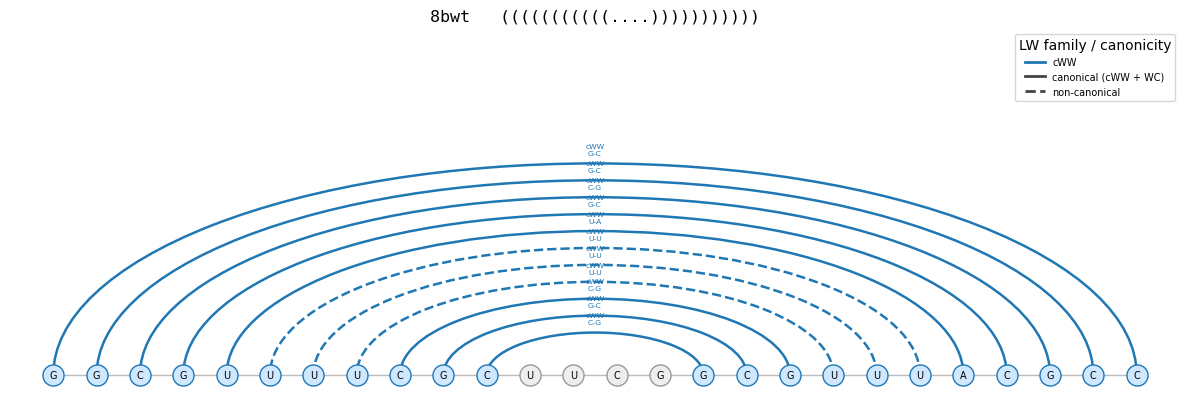

In [4]:
uniq = {}
for u, v, d in G.edges(data=True):
    if d['LW'] not in ('B53', 'B35'):
        uniq[frozenset((u, v))] = d['LW']
order = sorted(G.nodes, key=lambda n: G.nodes[n]['index'])
xpos = {n: k for k, n in enumerate(order)}
paired = {n for pair in uniq for n in pair}
db = ['.'] * len(order)

fams = sorted(set(uniq.values()))                          # one colour per LW family
palette = dict(zip(fams, plt.get_cmap('tab10').colors))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot([0, len(order) - 1], [0, 0], color='#bbb', lw=1, zorder=0)
for n in order:
    x, p = xpos[n], n in paired
    ax.scatter([x], [0], s=230, zorder=3, color='#cfe8ff' if p else '#eee',
               edgecolors='#1f77b4' if p else '#999')
    ax.text(x, 0, G.nodes[n]['nt_code'], ha='center', va='center', fontsize=7, zorder=4)
for pair, fam in uniq.items():
    na, nb = sorted(pair, key=xpos.get)                    # left/right by position
    b1, b2 = G.nodes[na]['nt_code'], G.nodes[nb]['nt_code']
    a, b = xpos[na], xpos[nb]
    db[a], db[b] = '(', ')'
    w = b - a
    col = palette[fam]
    # solid = CANONICAL (cWW *and* A-U/G-C); dashed = non-canonical (incl. cWW U-U)
    canon = rna_pairs.is_canonical(fam, b1, b2)
    ax.add_patch(Arc(((a + b) / 2, 0), w, w * 0.7, theta1=0, theta2=180,
                     color=col, lw=1.8, linestyle='-' if canon else '--', zorder=2))
    # class label = LW family + base combination
    ax.text((a + b) / 2, w * 0.35 + 0.3, f"{fam}\n{b1}-{b2}",
            ha='center', va='bottom', fontsize=5.5, color=col, zorder=5)
ax.legend(handles=[plt.Line2D([0], [0], color=palette[f], lw=2, label=f) for f in fams]
          + [plt.Line2D([0], [0], color='#444', lw=2, ls='-', label='canonical (cWW + WC)'),
             plt.Line2D([0], [0], color='#444', lw=2, ls='--', label='non-canonical')],
          loc='upper right', fontsize=7, title='LW family / canonicity')
ax.set_xlim(-1, len(order))
ax.set_ylim(-1, len(order) * 0.55)
ax.axis('off')
ax.set_title(f"{G.graph['pdbid']}   {''.join(db)}", fontfamily='monospace')
plt.tight_layout(); plt.show()

## Step 4 — backbone-aware 2D layout (networkx)

The same graph, folded by a force-directed layout that respects the backbone — so it forms the
hairpin/stem shape. Nodes coloured by nucleotide; edges coloured by **canonical** (cWW *and*
a Watson-Crick combo A·U/G·C, blue), **non-canonical** (everything else incl. `cWW_U-U`, red dashed),
and backbone (gray) — the same base-aware definition as Step 3.

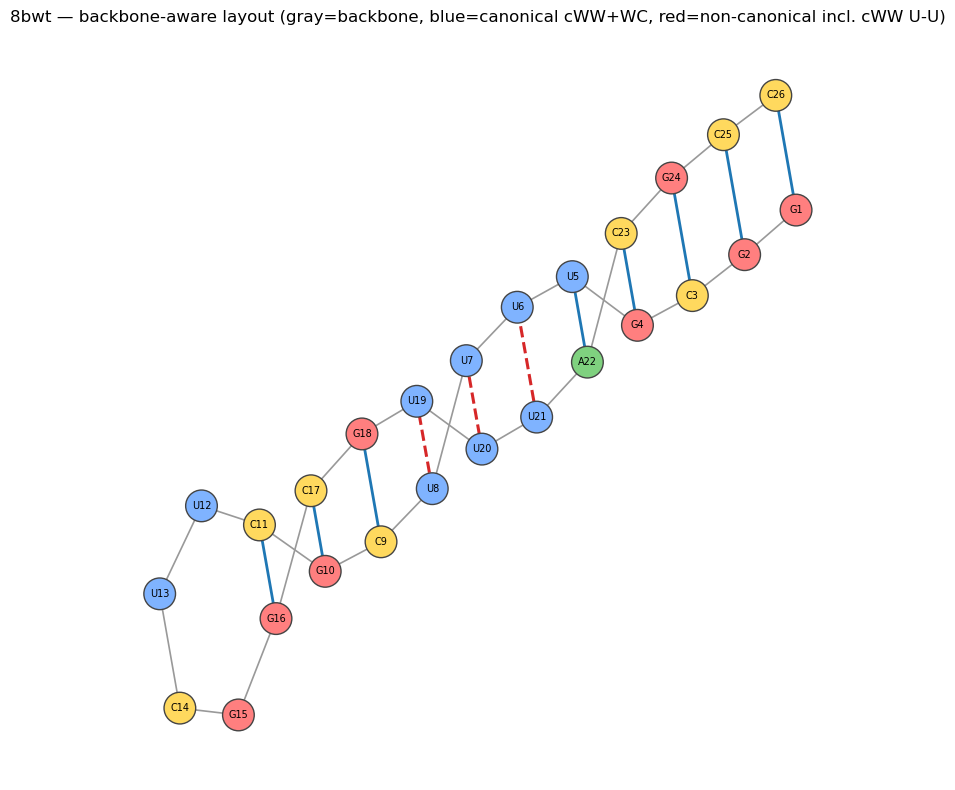

In [5]:
S = nx.Graph()
S.add_nodes_from(G.nodes(data=True))
for u, v, d in G.edges(data=True):
    if not S.has_edge(u, v):
        S.add_edge(u, v, LW=d['LW'])
layout = nx.kamada_kawai_layout(S)
NT_COLOR = {'A': '#7fd17f', 'C': '#ffd95e', 'G': '#ff7f7f', 'U': '#7fb3ff'}
node_colors = [NT_COLOR.get(S.nodes[n]['nt_code'], '#bbb') for n in S]


def edge_kind(u, v, d):
    # canonical is base-aware: cWW *and* a Watson-Crick combo (A-U / G-C); cWW_U-U is non-canonical
    if d['LW'] in ('B53', 'B35'):
        return 'backbone'
    return ('canonical' if rna_pairs.is_canonical(d['LW'], S.nodes[u]['nt_code'], S.nodes[v]['nt_code'])
            else 'noncanonical')


styles = {'backbone': ('#999999', 'solid', 1.2),
          'canonical': ('#1f77b4', 'solid', 2.0),
          'noncanonical': ('#d62728', 'dashed', 2.2)}

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_nodes(S, layout, node_color=node_colors, edgecolors='#444', node_size=520, ax=ax)
nx.draw_networkx_labels(S, layout, labels={n: f"{S.nodes[n]['nt_code']}{S.nodes[n]['index']}" for n in S},
                        font_size=7, ax=ax)
for kind, (color, style, wdt) in styles.items():
    es = [(u, v) for u, v, d in S.edges(data=True) if edge_kind(u, v, d) == kind]
    nx.draw_networkx_edges(S, layout, edgelist=es, edge_color=color, style=style, width=wdt, ax=ax)
ax.set_title(f"{G.graph['pdbid']} — backbone-aware layout "
             f"(gray=backbone, blue=canonical cWW+WC, red=non-canonical incl. cWW U-U)")
ax.axis('off'); plt.tight_layout(); plt.show()

## Step 5 — coordinates / geometry (DNATCO)

The annotation file has no atoms. DNATCO "extended" cifs carry experimental coordinates;
`dnatco_cif_to_graph` keeps three representative atoms per nucleotide (C1′, glycosidic N, P).
Below: the 3D C1′ trace of a coordinate structure.

coordinate structure: 1ehz | 76/76 nodes have C1' coords


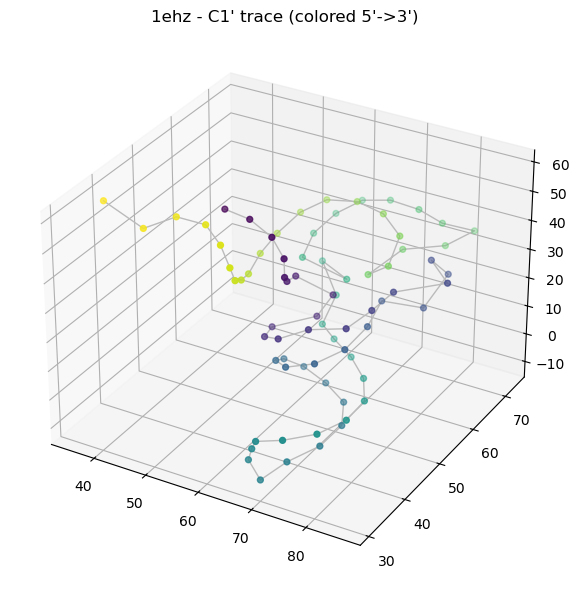

In [6]:
from dnatco_to_graph import dnatco_cif_to_graph

def find_or_fetch_cif(prefer='1ehz'):
    dirs = [PKG / 'rs25' / 'cifs', PKG / 'demo' / 'cifs']
    for d in dirs:                                   # prefer a clean single-chain RNA
        if (d / f'{prefer}.cif').exists():
            return d / f'{prefer}.cif'
    for d in dirs:
        if d.is_dir():
            for f in sorted(d.glob('*.cif')):
                return f
    from dnatco_fetch import fetch_one               # fallback: fetch one small structure
    out = PKG / 'walkthrough' / '_cif'
    out.mkdir(parents=True, exist_ok=True)
    fetch_one(prefer, out, False)
    return out / f'{prefer}.cif'

cif = find_or_fetch_cif()
Gc = dnatco_cif_to_graph(cif)
cov = sum('xyz_C1p' in d for _, d in Gc.nodes(data=True))
print(f"coordinate structure: {Gc.graph['pdbid']} | {cov}/{Gc.number_of_nodes()} nodes have C1' coords")

pg = rna_pairs.parse_graph(Gc)
pts = np.array([c for c in pg.c1 if c is not None])
ax = plt.figure(figsize=(6, 6)).add_subplot(projection='3d')
ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], '-', color='#bbb', lw=1)
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=18, c=np.arange(len(pts)), cmap='viridis')
ax.set_title(f"{Gc.graph['pdbid']} - C1' trace (colored 5'->3')")
plt.tight_layout(); plt.show()

## Step 6 — what the model sees: candidate pairs + geometry

The contact/detect models score **candidate pairs**: the true base pairs (positives) plus
spatially-close **hard negatives** (KD-tree). Their C1′–C1′ distances *overlap* — which is exactly
why a plain distance threshold isn't enough and the GNN has to use identity + context.

28 positive pairs | 28 hard negatives


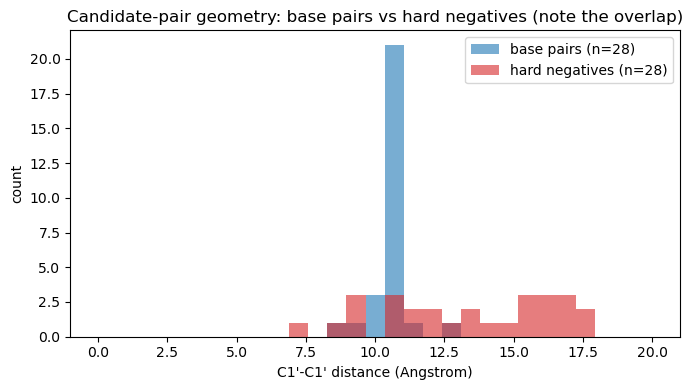

In [7]:
pos = {(lo, hi) for lo, hi, _ in pg.base_pairs if pg.c1[lo] is not None and pg.c1[hi] is not None}
rng = np.random.default_rng(0)
negs = rna_pairs.sample_hard_negatives(pg.c1, pg.seq, pg.chain, pos, cutoff=18.0, n_neg=len(pos), rng=rng)
dist = lambda s: [float(np.linalg.norm(pg.c1[a] - pg.c1[b])) for a, b in s]
dp, dn = dist(pos), dist(negs)
print(f"{len(pos)} positive pairs | {len(negs)} hard negatives")

plt.figure(figsize=(7, 4))
bins = np.linspace(0, 20, 30)
plt.hist(dp, bins=bins, alpha=0.6, label=f'base pairs (n={len(dp)})', color='#1f77b4')
plt.hist(dn, bins=bins, alpha=0.6, label=f'hard negatives (n={len(dn)})', color='#d62728')
plt.xlabel("C1'-C1' distance (Angstrom)"); plt.ylabel('count'); plt.legend()
plt.title('Candidate-pair geometry: base pairs vs hard negatives (note the overlap)')
plt.tight_layout(); plt.show()